In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import os

In [ ]:
def catch_hh_vacancies(query = "Разработчик", only_with_salary = True, target = 2000, per_page = 100):
    headers = {"User-Agent": "hh-anomaly-script"}
    items = []
    page = 0
    while len(items) < target:
        params = {
            "text": query,
            "only_with_salary": str(only_with_salary).lower(),
            "per_page": per_page,
            "page": page
        }
        resp = requests.get("https://api.hh.ru/vacancies", params = params, headers = headers)
        if resp.status_code != 200:
            raise RuntimeError(f"hh API вернул {resp.status_code}: {resp.text}")
        data = resp.json()
        page_items = data.get("items", [])
        if not page_items:
            break
        items.extend(page_items)
        print(f"Выбранная страница {page}: {len(page_items)} items, total {len(items)}")
        page += 1
        if page > 500:
            break
    return items[:target]

In [ ]:
def items_to_dataframe(items):
    df = pd.json_normalize(items)
    keep = [
        "id",
        "name",
        "area.name",
        "salary.from",
        "salary.to",
        "salary.gross",
        "salary.currency",
        "snippet.requirement",
        "experience.name",
        "alternate_url"
    ]
    for col in keep:
        if col not in df.columns:
            df[col] = np.nan
    df = df[["id","name","area.name","salary.from","salary.to","salary.gross","salary.currency","snippet.requirement","experience.name","alternate_url"]]
    return df

In [ ]:
df = items_to_dataframe(catch_hh_vacancies())

Выбранная страница 0: 100 items, total 100
Выбранная страница 1: 100 items, total 200
Выбранная страница 2: 100 items, total 300
Выбранная страница 3: 100 items, total 400
Выбранная страница 4: 100 items, total 500
Выбранная страница 5: 100 items, total 600
Выбранная страница 6: 100 items, total 700
Выбранная страница 7: 100 items, total 800
Выбранная страница 8: 100 items, total 900
Выбранная страница 9: 100 items, total 1000
Выбранная страница 10: 100 items, total 1100
Выбранная страница 11: 100 items, total 1200
Выбранная страница 12: 100 items, total 1300
Выбранная страница 13: 100 items, total 1400
Выбранная страница 14: 100 items, total 1500
Выбранная страница 15: 100 items, total 1600
Выбранная страница 16: 100 items, total 1700
Выбранная страница 17: 100 items, total 1800
Выбранная страница 18: 100 items, total 1900
Выбранная страница 19: 100 items, total 2000


In [ ]:
df.head(10)

,id,name,area.name,salary.from,salary.to,salary.gross,salary.currency,snippet.requirement,experience.name,alternate_url
0,125687280,React (middle) разработчик,Самарканд,8000000.0,15000000.0,False,UZS,1. Опыт работы с React: - Уверенное знание Rea...,От 3 до 6 лет,https://hh.ru/vacancy/125687280
1,125826541,Frontend-разработчик,Астана,500000.0,800000.0,False,KZT,Опыт коммерческой разработки от 2 лет. Отлично...,От 1 года до 3 лет,https://hh.ru/vacancy/125826541
2,125591665,Front-end Разработчик - Next.JS / React (Stron...,Бишкек,60000.0,70000.0,False,KGS,Отличные знания языков и опыт коммерческой ра...,От 3 до 6 лет,https://hh.ru/vacancy/125591665
3,125749469,React Developer,Астана,NaN,400000.0,False,KZT,Опыт работы с React от 1 лет. Глубокие знания ...,От 1 года до 3 лет,https://hh.ru/vacancy/125749469
4,125593732,Backend-разработчик,Ташкент,1000.0,2000.0,True,USD,От 2 лет коммерческого опыта в backend-разрабо...,От 1 года до 3 лет,https://hh.ru/vacancy/125593732
5,125474384,Front-End Developer,Алматы,NaN,800000.0,False,KZT,4+ лет опыта в веб-разработке. Отличное знание...,От 3 до 6 лет,https://hh.ru/vacancy/125474384
6,125827310,Старший Юрист,Алматы,800000.0,NaN,False,KZT,Требуемый опыт работы: от 6 лет. 1) Знание тре...,Более 6 лет,https://hh.ru/vacancy/125827310
7,125689509,Python Backend-разработчик,Алматы,300000.0,NaN,True,KZT,Опыт работы с Python (FastAPI или аналогичные ...,От 1 года до 3 лет,https://hh.ru/vacancy/125689509
8,125479486,Java-разработчик,Астана,200000.0,500000.0,True,KZT,"Уверенное владение Java 11+ (лямбда-выражения,...",От 1 года до 3 лет,https://hh.ru/vacancy/125479486
9,125731793,Бухгалтер,Ташкент,NaN,2200.0,False,USD,Бухгалтер со знаниями Программирования / Автом...,От 1 года до 3 лет,https://hh.ru/vacancy/125731793


In [ ]:
rates = { "USD": 84.38,
        "EUR": 99.33,
        "KZT": 0.156581,
        "BYR": 27.38,
        "UZS": 0.006692,
        "KGS": 0.964892,
        "GEL": 31.3225,
        "RUR": 1.0}

In [ ]:
def add_avarage_sal(df):
    def compute_row(r):
        sal_from = r["salary.from"]
        sal_to = r["salary.to"]
        if pd.notnull(sal_from) and pd.notnull(sal_to):
            try:
                return (float(sal_from) + float(sal_to)) / 2.0
            except:
                return np.nan
        if pd.notnull(sal_from):
            try:
                return float(sal_from)
            except:
                return np.nan
        if pd.notnull(sal_to):
            try:
                return float(sal_to)
            except:
                return np.nan
        return np.nan
    df["salary.avarage"] = df.apply(compute_row, axis=1)
    return df

In [ ]:
df = add_avarage_sal(df)
df.head(10)

,id,name,area.name,salary.from,salary.to,salary.gross,salary.currency,snippet.requirement,experience.name,alternate_url,salary.avarage
0,125687280,React (middle) разработчик,Самарканд,8000000.0,15000000.0,False,UZS,1. Опыт работы с React: - Уверенное знание Rea...,От 3 до 6 лет,https://hh.ru/vacancy/125687280,11500000.0
1,125826541,Frontend-разработчик,Астана,500000.0,800000.0,False,KZT,Опыт коммерческой разработки от 2 лет. Отлично...,От 1 года до 3 лет,https://hh.ru/vacancy/125826541,650000.0
2,125591665,Front-end Разработчик - Next.JS / React (Stron...,Бишкек,60000.0,70000.0,False,KGS,Отличные знания языков и опыт коммерческой ра...,От 3 до 6 лет,https://hh.ru/vacancy/125591665,65000.0
3,125749469,React Developer,Астана,NaN,400000.0,False,KZT,Опыт работы с React от 1 лет. Глубокие знания ...,От 1 года до 3 лет,https://hh.ru/vacancy/125749469,400000.0
4,125593732,Backend-разработчик,Ташкент,1000.0,2000.0,True,USD,От 2 лет коммерческого опыта в backend-разрабо...,От 1 года до 3 лет,https://hh.ru/vacancy/125593732,1500.0
5,125474384,Front-End Developer,Алматы,NaN,800000.0,False,KZT,4+ лет опыта в веб-разработке. Отличное знание...,От 3 до 6 лет,https://hh.ru/vacancy/125474384,800000.0
6,125827310,Старший Юрист,Алматы,800000.0,NaN,False,KZT,Требуемый опыт работы: от 6 лет. 1) Знание тре...,Более 6 лет,https://hh.ru/vacancy/125827310,800000.0
7,125689509,Python Backend-разработчик,Алматы,300000.0,NaN,True,KZT,Опыт работы с Python (FastAPI или аналогичные ...,От 1 года до 3 лет,https://hh.ru/vacancy/125689509,300000.0
8,125479486,Java-разработчик,Астана,200000.0,500000.0,True,KZT,"Уверенное владение Java 11+ (лямбда-выражения,...",От 1 года до 3 лет,https://hh.ru/vacancy/125479486,350000.0
9,125731793,Бухгалтер,Ташкент,NaN,2200.0,False,USD,Бухгалтер со знаниями Программирования / Автом...,От 1 года до 3 лет,https://hh.ru/vacancy/125731793,2200.0


In [ ]:
df['area.name'].unique()

array(['Самарканд', 'Астана', 'Бишкек', 'Ташкент', 'Алматы', 'Шымкент',
       'Москва', 'Альметьевск', 'Минск', 'Санкт-Петербург',
       'Екатеринбург', 'Кострома', 'Йошкар-Ола', 'Могилев', 'США',
       'Челябинск', 'Ярославль', 'Омск', 'Ростов-на-Дону', 'Курган',
       'Ижевск', 'Ставрополь', 'Красноярск', 'Испания', 'Краснодар',
       'Обнинск', 'Нижний Новгород', 'Каспийск', 'Тюмень', 'Воронеж',
       'Гродно', 'Тольятти', 'Томск', 'Абакан', 'Орск', 'Барнаул',
       'Самара', 'Казань', 'Южно-Сахалинск', 'Брянск',
       'Ревда (Свердловская область)', 'Тамбов', 'Мальта', 'Новосибирск',
       'Махачкала', 'Рязань', 'Донецк', 'Зеленоград', 'Вологда',
       'Киров (Кировская область)', 'Сербия', 'Оренбург', 'Шахты',
       'Иркутск', 'Чебоксары', 'Ульяновск',
       'Уральский (Удмуртская Республика)', 'Уфа', 'Пермь', 'Баку',
       'Лорино (Чукотский АО)', 'Чехов (Московская область)', 'Иннополис',
       'Пенза', 'Новокузнецк', 'Костанай', 'Караганда',
       'Фрязино (Моско

In [ ]:
countries = {
    'Астана': 'Казахстан',
    'Алматы': 'Казахстан',
    'Шымкент': 'Казахстан',
    'Караганда': 'Казахстан',
    'Костанай': 'Казахстан',
    'Павлодар': 'Казахстан',
    'Усть-Каменогорск': 'Казахстан',
    'Актау': 'Казахстан',
    'Актобе': 'Казахстан',
    'Самарканд': 'Узбекистан',
    'Ташкент': 'Узбекистан',
    'Нукус': 'Узбекистан',
    'Навои': 'Узбекистан',
    'Термез': 'Узбекистан',
    'Бишкек': 'Кыргызстан',
    'Минск': 'Беларусь',
    'Могилев': 'Беларусь',
    'Гродно': 'Беларусь',
    'Брест': 'Беларусь',
    'Гомель': 'Беларусь',
    'Бобруйск': 'Беларусь',
    'Витебск': 'Беларусь',
    'Кобрин': 'Беларусь',
    'Москва': 'Россия',
    'Санкт-Петербург': 'Россия',
    'Екатеринбург': 'Россия',
    'Кострома': 'Россия',
    'Йошкар-Ола': 'Россия',
    'Ярославль': 'Россия',
    'Омск': 'Россия',
    'Челябинск': 'Россия',
    'Ростов-на-Дону': 'Россия',
    'Красноярск': 'Россия',
    'Ижевск': 'Россия',
    'Курган': 'Россия',
    'Ставрополь': 'Россия',
    'Обнинск': 'Россия',
    'Нижний Новгород': 'Россия',
    'Краснодар': 'Россия',
    'Тюмень': 'Россия',
    'Каспийск': 'Россия',
    'Тольятти': 'Россия',
    'Воронеж': 'Россия',
    'Томск': 'Россия',
    'Барнаул': 'Россия',
    'Самара': 'Россия',
    'Абакан': 'Россия',
    'Орск': 'Россия',
    'Казань': 'Россия',
    'Рязань': 'Россия',
    'Ревда (Свердловская область)': 'Россия',
    'Брянск': 'Россия',
    'Новосибирск': 'Россия',
    'Махачкала': 'Россия',
    'Южно-Сахалинск': 'Россия',
    'Зеленоград': 'Россия',
    'Вологда': 'Россия',
    'Киров (Кировская область)': 'Россия',
    'Шахты': 'Россия',
    'Иркутск': 'Россия',
    'Оренбург': 'Россия',
    'Чебоксары': 'Россия',
    'Ульяновск': 'Россия',
    'Уральский (Удмуртская Республика)': 'Россия',
    'Уфа': 'Россия',
    'Пермь': 'Россия',
    'Чехов (Московская область)': 'Россия',
    'Иннополис': 'Россия',
    'Лорино (Чукотский АО)': 'Россия',
    'Пенза': 'Россия',
    'Новокузнецк': 'Россия',
    'Фрязино (Московская область)': 'Россия',
    'Благовещенск (Амурская область)': 'Россия',
    'Кемерово': 'Россия',
    'Калининград': 'Россия',
    'Пятигорск': 'Россия',
    'Курск': 'Россия',
    'Сыктывкар': 'Россия',
    'Астрахань': 'Россия',
    'Саратов': 'Россия',
    'Таганрог': 'Россия',
    'Волгоград': 'Россия',
    'Петропавловск-Камчатский': 'Россия',
    'Улан-Удэ': 'Россия',
    'Владивосток': 'Россия',
    'Чита': 'Россия',
    'Сургут': 'Россия',
    'Щелково (Московская область)': 'Россия',
    'Новороссийск': 'Россия',
    'Магнитогорск': 'Россия',
    'Электросталь (Московская область)': 'Россия',
    'Великий Новгород': 'Россия',
    'Адлер': 'Россия',
    'Калуга': 'Россия',
    'Сергиев Посад (Московская область)': 'Россия',
    'Орел': 'Россия',
    'Ангарск': 'Россия',
    'Симферополь': 'Россия',
    'Одинцово (Московская область)': 'Россия',
    'Владимир': 'Россия',
    'Звенигород (Московская область)': 'Россия',
    'Нижний Тагил': 'Россия',
    'Хабаровск': 'Россия',
    'Псков': 'Россия',
    'Тверь': 'Россия',
    'Реутов (Московская область)': 'Россия',
    'Сочи': 'Россия',
    'Тула': 'Россия',
    'Иваново (Ивановская область)': 'Россия',
    'Дмитров (Московская область)': 'Россия',
    'Пушкино (Московская область)': 'Россия',
    'Наро-Фоминск (Московская область)': 'Россия',
    'Раменское (Московская область)': 'Россия',
    'Среднеуральск': 'Россия',
    'Люберцы  (Московская область)': 'Россия',
    'Лебедянь': 'Россия',
    'Ковров': 'Россия',
    'Ступино (Московская область)': 'Россия',
    'Магадан': 'Россия',
    'Архангельск': 'Россия',
    'Якутск': 'Россия',
    'Майкоп': 'Россия',
    'Смоленск': 'Россия',
    'Туапсе': 'Россия',
    'Шушары': 'Россия',
    'Орехово-Зуево (Московская область)': 'Россия',
    'Муром': 'Россия',
    'Серпухов (Московская область)': 'Россия',
    'Железнодорожный  (Московская область)': 'Россия',
    'Электроугли (Московская область)': 'Россия',
    'Жуковский  (Московская область)': 'Россия',
    'Дубки (Дагестан)': 'Россия',
    'Петрозаводск': 'Россия',
    'Нальчик': 'Россия',
    'Химки (Московская область)': 'Россия',
    'Подольск (Московская область)': 'Россия',
    'Белгород': 'Россия',
    'Саранск': 'Россия',
    'Набережные Челны': 'Россия',
    'Черкесск': 'Россия',
    'Черемхово': 'Россия',
    'Новочебоксарск': 'Россия',
    'Селятино (Московская область)': 'Россия',
    'Мытищи (Московская область)': 'Россия',
    'Донецк': 'Россия',
    'Луганск': 'Россия',
    'Севастополь': 'Россия',
    'Тбилиси': 'Грузия',
    'Батуми': 'Грузия',
    'Баку': 'Азербайджан',
    'США': 'США',
    'Испания': 'Испания',
    'Мальта': 'Мальта',
    'Сербия': 'Сербия',
    'ОАЭ': 'ОАЭ',
    'Аргентина': 'Аргентина',
    'Индия': 'Индия',
    'Хорватия': 'Хорватия',
    'Королевство Саудовская Аравия': 'Саудовская Аравия',
    'Черногория': 'Черногория',
    'Кипр': 'Кипр',
    'Индонезия': 'Индонезия'
}
taxes = {
    "Россия": 0.13,
    "Беларусь": 0.13,
    "Казахстан": 0.10,
    "Узбекистан": 0.12,
    "Кыргызстан": 0.10,
    "США": 0.25,
    "Испания": 0.24,
    "Сербия": 0.10,
    "Мальта": 0.25,
    "ОАЭ": 0.00,
    "Аргентина": 0.30,
    "Индия": 0.20,
    "Хорватия": 0.20,
    "Черногория": 0.15,
    "Индонезия": 0.10,
    "Кипр": 0.20,
    "Саудовская Аравия": 0.00,
    "Грузия": 0.18,
    "Азербайджан": 0.18
}


In [ ]:
def after_taxes(r):
    sal = r["salary.avarage"]
    gross = r["salary.gross"]
    city = r["area.name"]
    country = countries.get(city, "Неизвестно")
    r["country"] = country
    tax = taxes.get(country, 0.0)
    if gross is True and sal is not None:
        return sal * (1 - tax)
    else:
        return sal

In [ ]:
df["salary.after_taxes"] = df.apply(after_taxes, axis=1)
df.head(10)

,id,name,area.name,salary.from,salary.to,salary.gross,salary.currency,snippet.requirement,experience.name,alternate_url,salary.avarage,salary.after_taxes
0,125687280,React (middle) разработчик,Самарканд,8000000.0,15000000.0,False,UZS,1. Опыт работы с React: - Уверенное знание Rea...,От 3 до 6 лет,https://hh.ru/vacancy/125687280,11500000.0,11500000.0
1,125826541,Frontend-разработчик,Астана,500000.0,800000.0,False,KZT,Опыт коммерческой разработки от 2 лет. Отлично...,От 1 года до 3 лет,https://hh.ru/vacancy/125826541,650000.0,650000.0
2,125591665,Front-end Разработчик - Next.JS / React (Stron...,Бишкек,60000.0,70000.0,False,KGS,Отличные знания языков и опыт коммерческой ра...,От 3 до 6 лет,https://hh.ru/vacancy/125591665,65000.0,65000.0
3,125749469,React Developer,Астана,NaN,400000.0,False,KZT,Опыт работы с React от 1 лет. Глубокие знания ...,От 1 года до 3 лет,https://hh.ru/vacancy/125749469,400000.0,400000.0
4,125593732,Backend-разработчик,Ташкент,1000.0,2000.0,True,USD,От 2 лет коммерческого опыта в backend-разрабо...,От 1 года до 3 лет,https://hh.ru/vacancy/125593732,1500.0,1320.0
5,125474384,Front-End Developer,Алматы,NaN,800000.0,False,KZT,4+ лет опыта в веб-разработке. Отличное знание...,От 3 до 6 лет,https://hh.ru/vacancy/125474384,800000.0,800000.0
6,125827310,Старший Юрист,Алматы,800000.0,NaN,False,KZT,Требуемый опыт работы: от 6 лет. 1) Знание тре...,Более 6 лет,https://hh.ru/vacancy/125827310,800000.0,800000.0
7,125689509,Python Backend-разработчик,Алматы,300000.0,NaN,True,KZT,Опыт работы с Python (FastAPI или аналогичные ...,От 1 года до 3 лет,https://hh.ru/vacancy/125689509,300000.0,270000.0
8,125479486,Java-разработчик,Астана,200000.0,500000.0,True,KZT,"Уверенное владение Java 11+ (лямбда-выражения,...",От 1 года до 3 лет,https://hh.ru/vacancy/125479486,350000.0,315000.0
9,125731793,Бухгалтер,Ташкент,NaN,2200.0,False,USD,Бухгалтер со знаниями Программирования / Автом...,От 1 года до 3 лет,https://hh.ru/vacancy/125731793,2200.0,2200.0


In [ ]:
df['salary.currency'].unique()

array(['UZS', 'KZT', 'KGS', 'USD', 'RUR', 'BYR', 'EUR', 'GEL'],
      dtype=object)

In [ ]:
currencies = {
    "KZT": 0.1532,
    "UZS": 0.00687,
    "KGS": 0.9534,
    "RUR": 1.0,
    "USD": 83.61,
    "BYR": 27.5313,
    "EUR": 97.56,
    "GEL": 36.0
}

In [ ]:
def currency_to_rub(r):
  cur = r['salary.currency']
  sal = r['salary.after_taxes']
  if sal is None:
    return None
  currency = currencies.get(cur, 1.0)
  currency = float(currency)
  return round(sal * currency)

In [ ]:
df['clean_sal'] = df.apply(currency_to_rub, axis=1)
df.head(10)

,id,name,area.name,salary.from,salary.to,salary.gross,salary.currency,snippet.requirement,experience.name,alternate_url,salary.avarage,salary.after_taxes,clean_sal
0,125687280,React (middle) разработчик,Самарканд,8000000.0,15000000.0,False,UZS,1. Опыт работы с React: - Уверенное знание Rea...,От 3 до 6 лет,https://hh.ru/vacancy/125687280,11500000.0,11500000.0,79005
1,125826541,Frontend-разработчик,Астана,500000.0,800000.0,False,KZT,Опыт коммерческой разработки от 2 лет. Отлично...,От 1 года до 3 лет,https://hh.ru/vacancy/125826541,650000.0,650000.0,99580
2,125591665,Front-end Разработчик - Next.JS / React (Stron...,Бишкек,60000.0,70000.0,False,KGS,Отличные знания языков и опыт коммерческой ра...,От 3 до 6 лет,https://hh.ru/vacancy/125591665,65000.0,65000.0,61971
3,125749469,React Developer,Астана,NaN,400000.0,False,KZT,Опыт работы с React от 1 лет. Глубокие знания ...,От 1 года до 3 лет,https://hh.ru/vacancy/125749469,400000.0,400000.0,61280
4,125593732,Backend-разработчик,Ташкент,1000.0,2000.0,True,USD,От 2 лет коммерческого опыта в backend-разрабо...,От 1 года до 3 лет,https://hh.ru/vacancy/125593732,1500.0,1320.0,110365
5,125474384,Front-End Developer,Алматы,NaN,800000.0,False,KZT,4+ лет опыта в веб-разработке. Отличное знание...,От 3 до 6 лет,https://hh.ru/vacancy/125474384,800000.0,800000.0,122560
6,125827310,Старший Юрист,Алматы,800000.0,NaN,False,KZT,Требуемый опыт работы: от 6 лет. 1) Знание тре...,Более 6 лет,https://hh.ru/vacancy/125827310,800000.0,800000.0,122560
7,125689509,Python Backend-разработчик,Алматы,300000.0,NaN,True,KZT,Опыт работы с Python (FastAPI или аналогичные ...,От 1 года до 3 лет,https://hh.ru/vacancy/125689509,300000.0,270000.0,41364
8,125479486,Java-разработчик,Астана,200000.0,500000.0,True,KZT,"Уверенное владение Java 11+ (лямбда-выражения,...",От 1 года до 3 лет,https://hh.ru/vacancy/125479486,350000.0,315000.0,48258
9,125731793,Бухгалтер,Ташкент,NaN,2200.0,False,USD,Бухгалтер со знаниями Программирования / Автом...,От 1 года до 3 лет,https://hh.ru/vacancy/125731793,2200.0,2200.0,183942


In [ ]:
def draw_boxplot(df):
  plt.figure(figsize=(8, 6))
  plt.boxplot(df["clean_sal"].dropna(), vert=True)
  plt.ylabel("Зарплата, рубли")
  plt.show()

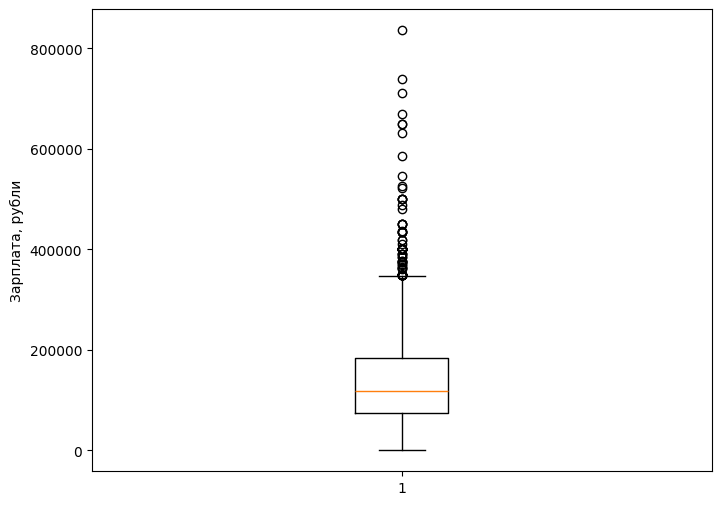

In [ ]:
import numpy as np
draw_boxplot(df)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
salary.from,1751.0,289587.215877,1.444623e+06,170.0,60000.00,100000.0,180000.0,30000000.0
salary.to,1260.0,465922.228571,2.444090e+06,300.0,90000.00,150000.0,250000.0,40000000.0
salary.avarage,2000.0,337018.156750,1.713113e+06,240.0,70000.00,125000.0,200000.0,35000000.0
salary.after_taxes,2000.0,321437.844980,1.598884e+06,208.8,70000.00,120000.0,200000.0,30800000.0
clean_sal,2000.0,140659.534000,9.425211e+04,209.0,73406.25,118630.5,183942.0,836100.0


In [ ]:
!pip install pyod

In [ ]:
df2 = df[["id", "name", "area.name", "experience.name", "clean_sal"]].copy()

In [ ]:
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.knn import KNN

In [ ]:
X = df2[['clean_sal']].values
models = [
    IForest(),
    KNN(),
    LOF()
]
for i, model in enumerate(models, 1):
    model.fit(X)
    df2[f'anomaly{i}'] = model.predict(X)
df2['anomaly'] = df2[['anomaly1', 'anomaly2', 'anomaly3']].sum(axis=1) >= 2
df2['anomaly'] = df2['anomaly'].astype(int)

In [ ]:
df2['anomaly'].value_counts()

,count
anomaly,
0,1841
1,159


In [ ]:
import math

In [ ]:
def explain_anomalies(df):
    q1 = df["clean_sal"].dropna().quantile(0.25)
    q3 = df["clean_sal"].dropna().quantile(0.75)
    mean = df["clean_sal"].median(skipna = True)
    iqr = q3 - q1
    #из-за большого межквартильного размаха для обнаружения аномалий, меньших "нижнего уса", берется логарифм от зарплаты
    log_low_border = math.log1p(q1) - 1.5 * (math.log1p(q3) - math.log1p(q1))
    high_border = q3 + 1.5 * iqr
    reasons = []
    for _, row in df.iterrows():
        if row["anomaly"] != 1:
            reasons.append("Вакансия не аномальная")
            continue
        sal = row["clean_sal"]
        exp = row.get("experience.name", "")
        area = row.get("area.name", "")
        if sal is not None:
          if "Нет опыта" in exp and sal > q3:
            reason = f"Для стажёра слишком высокая зарплата ({sal} RUR)"
          elif "Более 6 лет" in exp and sal < q1:
            reason = f"Для эксперта с {exp} слишком низкая зарплата ({sal} RUR)"
          elif ("Москва" in area or 'Санкт-Петербург' in area or 'США' in area or 'ОАЭ' in area) and sal < mean:
            reason = f"Для региона {area} слишком низкая зарплата ({sal} RUR)"
          elif not ("Москва" in area or 'Санкт-Петербург' in area or 'США' in area or 'ОАЭ' in area) and sal > mean:
            reason = f"Для региона {area} слишком высокая зарплата ({sal} RUR)"
          elif math.log1p(sal) < log_low_border:
            reason = f"Зарплата ({sal} RUR) слишком низкая, возможно неполный рабочий день, нижняя граница зарплаты или ошибка в оффере."
          elif sal > high_border:
            reason = f"Зарплата ({sal} RUR) слышком высокая зарплата, возможно это позиция сеньера/тимлида, верхняя граница зарплаты или достаточно редкий высокооплачиваемый оффер"
          else:
              reason = f"Неизвестная причина, возможно оффер некорректно составлен"
        else:
            reason = "Отсутствуют данные о зарплате"
        reasons.append(reason)
    df["anomaly_reason"] = reasons
    return df

In [ ]:
df2 = explain_anomalies(df2)

In [ ]:
df2[df2["anomaly"] == 1][["id", "name", "area.name", "experience.name", "clean_sal", "anomaly_reason"]]

,id,name,area.name,experience.name,clean_sal,anomaly_reason
13,125861157,"Full Stack Developer (Middle, Python)",Алматы,От 3 до 6 лет,137880,Для региона Алматы слишком высокая зарплата (1...
23,125564204,Тимлид проекта,Москва,Более 6 лет,522000,Зарплата (522000 RUR) слышком высокая зарплата...
26,125815581,Руководитель отдела продаж,Москва,От 3 до 6 лет,500000,Зарплата (500000 RUR) слышком высокая зарплата...
29,125722233,Financial director,Москва,Более 6 лет,739500,Зарплата (739500 RUR) слышком высокая зарплата...
45,125721659,Руководитель отдела маркетинга,Москва,Более 6 лет,361050,Зарплата (361050 RUR) слышком высокая зарплата...
...,...,...,...,...,...,...
1911,125343362,QA Automation Engineer / Тестировщик-автоматиз...,Москва,От 3 до 6 лет,292635,"Неизвестная причина, возможно оффер некорректн..."
1924,125241412,Генеральный директор (CEO) AI/SaaS-стартап,Санкт-Петербург,От 3 до 6 лет,375000,Зарплата (375000 RUR) слышком высокая зарплата...
1970,125565381,Senior Delphi разработчик,Санкт-Петербург,Более 6 лет,410000,Зарплата (410000 RUR) слышком высокая зарплата...
1976,124783047,Team Lead / Руководитель разработки,Москва,От 3 до 6 лет,435000,Зарплата (435000 RUR) слышком высокая зарплата...
